# AAV5 for SELECTIVITY -- 

In [17]:
import numpy as np
import pandas as pd
from pathlib import Path

# --- locate the confidential AAV5 organoid CSV (never commit / push / upload) ---
CSV_PATH = Path("AAV5_organoides.csv")
if not CSV_PATH.exists():
    here = Path.cwd()
    root = next(p for p in [here, *here.parents] if p.name == "Modelization_V2")
    CSV_PATH = root / "notebooks/notebooks/Selectivity/AAV5/AAV5_organoides.csv"
assert CSV_PATH.exists(), CSV_PATH
print(CSV_PATH)


AAV5_organoides.csv


In [18]:
# 5.6M rows x 35 cols. Counts are fractional in AAV5 (multi-mapping split) -> floats.
# log2_enrichissement_* columns are mostly NaN (0 organoid/nuclei counts -> undefined log).
count_cols = [
    "compte_plasmide", "compte_virus",
    "compte_organoide_1_adn", "compte_organoide_1_arn",
    "compte_organoide_2_adn", "compte_organoide_2_arn",
    "compte_organoide_3_adn", "compte_organoide_3_arn",
    "compte_noyaux_1_adn", "compte_noyaux_1_arn",
    "compte_noyaux_2_adn", "compte_noyaux_2_arn",
    "compte_noyaux_moyenne_adn", "compte_noyaux_moyenne_arn",
    "compte_controle_negatif",
]
dtypes = {"sequence": "string", **{c: "float32" for c in count_cols}}
log2_cols = [c for c in pd.read_csv(CSV_PATH, nrows=0).columns if c.startswith("log2_")]
dtypes.update({c: "float32" for c in log2_cols})

df = pd.read_csv(CSV_PATH, dtype=dtypes)
df["sequence"] = df["sequence"].astype("string")
print(df.shape)
df.head()


(5595543, 35)


,sequence,compte_plasmide,compte_virus,log2_enrichissement_virus_sur_plasmide,compte_organoide_1_adn,compte_organoide_1_arn,log2_enrichissement_organoide_1_adn_sur_virus,log2_enrichissement_organoide_1_arn_sur_virus,log2_enrichissement_organoide_1_arn_sur_adn,compte_organoide_2_adn,...,compte_noyaux_2_arn,log2_enrichissement_noyaux_2_adn_sur_virus,log2_enrichissement_noyaux_2_arn_sur_virus,log2_enrichissement_noyaux_2_arn_sur_adn,compte_noyaux_moyenne_adn,compte_noyaux_moyenne_arn,log2_enrichissement_noyaux_moyenne_adn_sur_virus,log2_enrichissement_noyaux_moyenne_arn_sur_virus,log2_enrichissement_noyaux_moyenne_arn_sur_adn,compte_controle_negatif
0,TEVDRMT,36.5,0.5,-4.928953,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
1,VPQEVVR,8.5,50.5,3.831620,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
2,TGRSDAQ,10.0,8.5,1.026406,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
3,PIRINSN,14.5,1.0,-2.597110,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
4,GDTIAMV,8.5,6.0,0.758371,0.0,0.0,NaN,NaN,NaN,6.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0


In [19]:
# quick sanity: 7-mer length, alphabet, per-column NaN / zero fractions
seq_len = df["sequence"].str.len()
print("sequence length:", seq_len.min(), "-", seq_len.max())
print("alphabet:", "".join(sorted(set("".join(df["sequence"].head(100000))))))

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nan_frac": df.isna().mean().round(4),
})
num = df.select_dtypes("number")
overview["zero_frac"] = (num == 0).mean().round(4)
#overview


sequence length: 7 - 7
alphabet: ACDEFGHIKLMNPQRSTVWY


## 1. Analysis of the hyperparameters

In [20]:
# nombre total de counts par colonne (somme sur les 5.6M variants)
focus = ["compte_plasmide", "compte_virus",
         "compte_organoide_1_adn", "compte_organoide_2_adn", "compte_organoide_3_adn"]

totals = pd.DataFrame({
    "total_counts": [df[c].to_numpy(np.float64).sum() for c in focus],
    "n_variants_>0": [int((df[c].to_numpy() > 0).sum()) for c in focus],
    "max_counts": [float(df[c].max()) for c in focus],
}, index=focus)
totals["mean_par_variant_detecte"] = totals["total_counts"] / totals["n_variants_>0"]
totals

,total_counts,n_variants_>0,max_counts,mean_par_variant_detecte
compte_plasmide,115712748.0,5045045,4845391.5,22.935920
compte_virus,176196080.5,5595543,3043832.5,31.488647
compte_organoide_1_adn,41266372.0,108370,2138988.0,380.791474
compte_organoide_2_adn,47085630.5,486844,2446622.5,96.716054
compte_organoide_3_adn,43130572.5,233974,1656887.0,184.339168


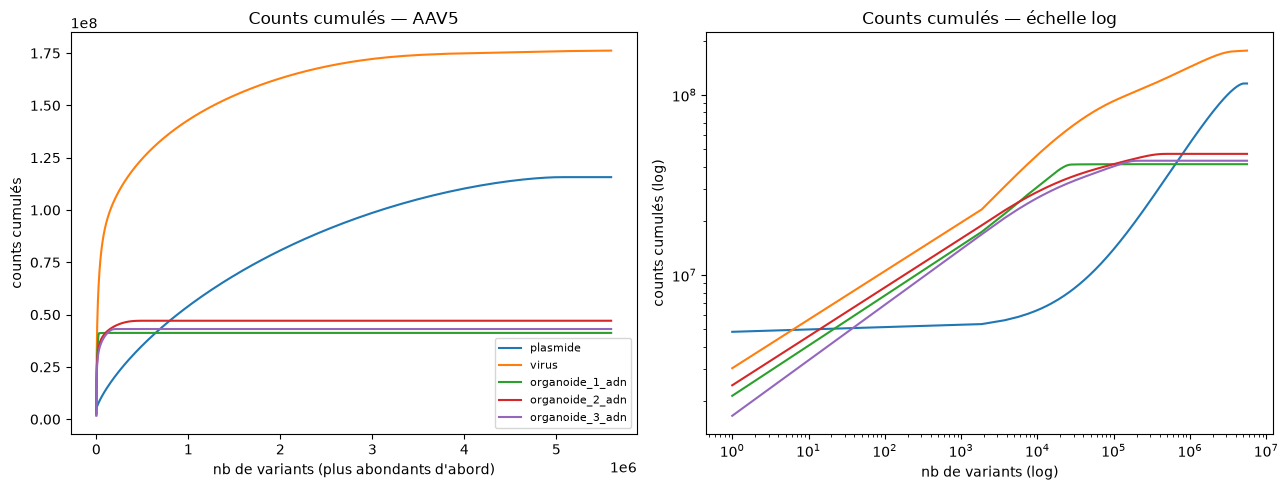

In [21]:
import matplotlib.pyplot as plt

# cumsum par colonne en counts absolus : variants triés par abondance decroissante,
# y = counts cumules. Une colonne a la fois (numpy), pas de df.cumsum().
def sorted_cumcounts(col, n=3000):
    v = np.sort(df[col].to_numpy(np.float64))[::-1]
    c = np.cumsum(v)
    q = np.linspace(0, v.size - 1, n).astype(int)
    return q + 1, c[q]          # x = nb de variants (rang), y = counts cumules

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for col in focus:
    x, c = sorted_cumcounts(col)
    axes[0].plot(x, c, label=col.replace("compte_", ""))
    axes[1].plot(x, c, label=col.replace("compte_", ""))
axes[0].set(xlabel="nb de variants (plus abondants d'abord)", ylabel="counts cumulés",
            title="Counts cumulés — AAV5")
axes[1].set(xscale="log", yscale="log",
            xlabel="nb de variants (log)", ylabel="counts cumulés (log)",
            title="Counts cumulés — échelle log")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Profondeur NGS `D` par checkpoint

Dans `Protocol`, chaque lecture NGS est `Multinomial(D, proportions)` → `D` = **somme des counts** de la colonne
(cf. `total_counts` ci-dessus) : plasmide ≈ 1.16e8, virus ≈ 1.76e8, ADN organoïde ≈ 4.1–4.7e7 par réplicat.
Top-100 par colonne ci-dessous pour juger de la dynamique (WT/spike-in `LGETTRP` en tête sur plasmide & virus).

In [22]:
TOPN = 100

# D par checkpoint + poids du top-100
D = pd.DataFrame({
    "D_total": [df[c].to_numpy(np.float64).sum() for c in focus],
    "top100_counts": [df[c].nlargest(TOPN).to_numpy(np.float64).sum() for c in focus],
}, index=[c.replace("compte_", "") for c in focus])
D["top100_frac"] = (D["top100_counts"] / D["D_total"]).round(3)
display(D)

# tableau des 100 sequences avec le plus de counts, par colonne
data = {}
for c in focus:
    name = c.replace("compte_", "")
    s = df[["sequence", c]].nlargest(TOPN, c).reset_index(drop=True)
    data[f"{name}_seq"] = s["sequence"].to_numpy()
    data[f"{name}_n"] = s[c].to_numpy()
top100 = pd.DataFrame(data, index=pd.RangeIndex(1, TOPN + 1, name="rang"))

with pd.option_context("display.max_rows", TOPN):
    display(top100)

,D_total,top100_counts,top100_frac
plasmide,115712748.0,4982365.5,0.043
virus,176196080.5,7572817.5,0.043
organoide_1_adn,41266372.0,6747722.5,0.164
organoide_2_adn,47085630.5,8073630.5,0.171
organoide_3_adn,43130572.5,6458452.0,0.150


,plasmide_seq,plasmide_n,virus_seq,virus_n,organoide_1_adn_seq,organoide_1_adn_n,organoide_2_adn_seq,organoide_2_adn_n,organoide_3_adn_seq,organoide_3_adn_n
rang,,,,,,,,,,
1,LGETTRP,4845391.5,LGETTRP,3043832.5,VRVRAVE,2138988.0,VRVRAVE,2446622.5,VRVRAVE,1656887.0
2,LGETTRH,16921.5,IADNRVS,361759.5,TQAGVHK,261748.5,TQAGVHK,337508.5,TQAGVHK,330856.5
3,TPANSTK,12492.5,NHPNSID,329851.0,LGETTRP,258603.0,VKAGNIL,274461.0,LGETTRP,199407.5
4,LCETTRP,7071.0,HDNKIMK,185091.0,VKAGNIL,224786.5,LGETTRP,273123.0,HDNKIMK,195463.5
5,LGETTIP,6615.5,LNTTRLT,157991.5,VKIRLVD,160986.0,HDNKIMK,247788.5,VKAGNIL,173868.0
6,IADNRVS,3480.0,KPMNATN,99325.0,HDNKIMK,141751.0,VKIRLVD,220598.0,LNTTRLT,159414.0
7,NHPNSID,3364.0,QKTHSQT,98226.5,LNTTRLT,135130.5,LNTTRLT,191149.0,VKIRLVD,152430.0
8,LPENSID,3001.5,HDINLTK,88038.0,IGTNMVR,115962.5,SKGPTSH,170997.5,SKGPTSH,152067.5
9,TTKKNSE,2177.5,INQANRV,80227.5,SKGPTSH,112724.5,IGTNMVR,117613.5,GNITNRV,92836.5


### There is a severe contamination by the 7m8 variant, also among the top 4 of most present variant, the first is the 7m8 and the second and fourth are mutation or misread of the 7m8 variant

## 2. Log2 enrichment — viability (virus / plasmide) & selectivity (ADN organoïde / virus)

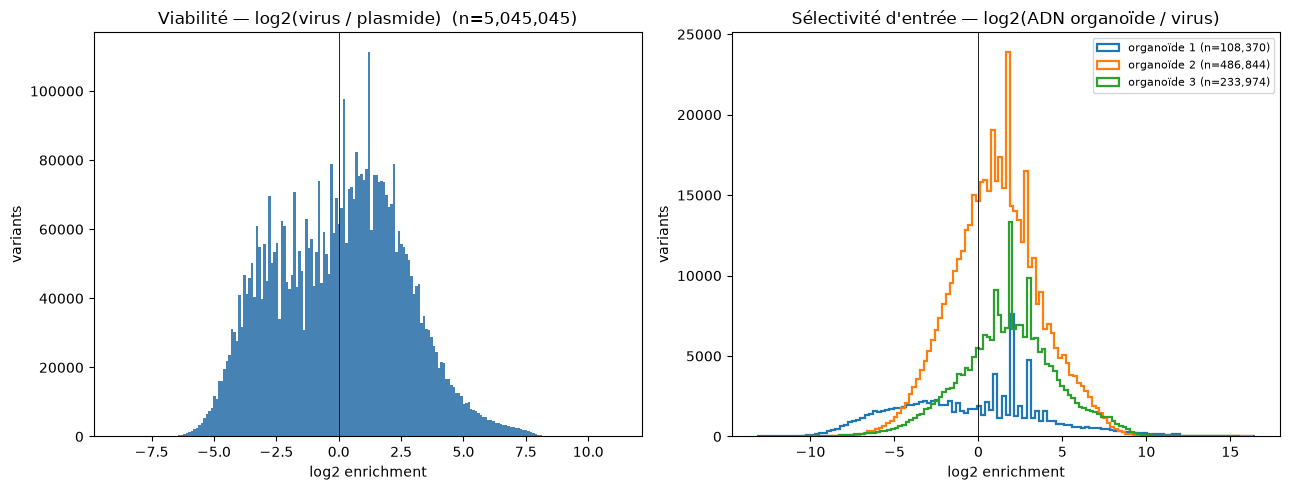

In [23]:
# viab = log2(virus / plasmide) ; sel = log2(ADN organoïde / virus), 3 réplicats organoïde
viab_col = "log2_enrichissement_virus_sur_plasmide"
sel_cols = [f"log2_enrichissement_organoide_{i}_adn_sur_virus" for i in (1, 2, 3)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

v = df[viab_col].to_numpy()
v = v[np.isfinite(v)]
axes[0].hist(v, bins=200, color="steelblue")
axes[0].axvline(0, color="k", lw=0.6)
axes[0].set(title=f"Viabilité — log2(virus / plasmide)  (n={v.size:,})",
            xlabel="log2 enrichment", ylabel="variants")

for i, col in zip((1, 2, 3), sel_cols):
    s = df[col].to_numpy()
    s = s[np.isfinite(s)]
    axes[1].hist(s, bins=120, histtype="step", lw=1.6, label=f"organoïde {i} (n={s.size:,})")
axes[1].axvline(0, color="k", lw=0.6)
axes[1].set(title="Sélectivité d'entrée — log2(ADN organoïde / virus)",
            xlabel="log2 enrichment", ylabel="variants")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Régression ridge Potts — GT viabilité + sélectivité

Même recette qu'`AAV9_potts_regression.ipynb` : `RegressionV1.fit_weights_potts_from_data`
(single-site one-hot + pairwise outer-product, 8541 features, ridge CV 5-fold sur λ) sur le
**log enrichment réel** de chaque cible. Un fit par cible :

- **viabilité** : `log2_enrichissement_virus_sur_plasmide`
- **sélectivité** : `log2_enrichissement_organoide_{1,2,3}_adn_sur_virus` (un GT par réplicat)

Sous-échantillonnage à `N_FIT` lignes (le design dense 5M×8541 float32 ≈ 170 GB sinon).
Validation Pearson r sur un held-out disjoint. Export `lib/aav5_{F,J}_*_potts.npy` (gitignorés
— données IDV confidentielles).

In [24]:
import sys, os

# robust lib path: walk up to Modelization_V2/ (the hardcoded ../../lib idiom resolves to
# Modelization_V1's pip-installed copy from this subfolder — cf. session brief).
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # before jax initializes (RegressionV1 imports jax)

import RegressionV1 as R
from analysisV1 import AA_LABELS, pearson

assert "Modelization_V2" in R.__file__, R.__file__
LIB = _root / "lib"
print(R.message, "|", R.__file__)

file regression 1.4 | /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/RegressionV1.py


In [25]:
# encode the 7-mers once (same recipe as AAV9_potts_regression.ipynb)
assert list(AA_LABELS) == sorted(set("".join(df["sequence"].head(200_000))))
L, A = 7, 20

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
seq_bytes = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), L)
print("seq_matrix:", seq_matrix.shape)


def score_FJ(seq, F, J):
    """F: (A, L)  J: (L, L, A, A)  ->  F_part + J_part per sequence."""
    F, J = np.asarray(F), np.asarray(J)
    Fp = F[seq, np.arange(L)].sum(axis=1).astype(np.float64)
    Jp = np.zeros(len(seq), dtype=np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            Jp += J[i, j, seq[:, i], seq[:, j]]
    return Fp + Jp

seq_matrix: (5595543, 7)


In [ ]:
from sklearn.model_selection import train_test_split

N_FIT   = 90_000                     # rows for the ridge fit (>> 8541 params)
N_EVAL  = 120_000                    # disjoint held-out rows
LAMBDAS = np.logspace(-2, 6, 25)     # very wide: we want to SEE where CV MSE actually turns
KFOLDS  = 3
CONTAM_MAX_PLASMID = 5e3             # exclude 7m8 (LGETTRP, plasmid 4.8M) + its misreads (next is ~17k)
RNG = np.random.default_rng(0)

# name -> (target col, denominator count col, numerator count col)
targets = {
    "viab":     ("log2_enrichissement_virus_sur_plasmide",       "compte_plasmide",       "compte_virus"),
    "sel_org1": ("log2_enrichissement_organoide_1_adn_sur_virus", "compte_virus", "compte_organoide_1_adn"),
    "sel_org2": ("log2_enrichissement_organoide_2_adn_sur_virus", "compte_virus", "compte_organoide_2_adn"),
    "sel_org3": ("log2_enrichissement_organoide_3_adn_sur_virus", "compte_virus", "compte_organoide_3_adn"),
}

contam = df["compte_plasmide"].to_numpy() >= CONTAM_MAX_PLASMID
print(f"{contam.sum()} variants exclus (contamination 7m8) : {df['sequence'][contam].tolist()}\n")

fits = {}
for name, (col, den_col, num_col) in targets.items():
    y_all = df[col].to_numpy(np.float64)
    c_den = df[den_col].to_numpy(np.float64)
    c_num = df[num_col].to_numpy(np.float64)
    # inverse-variance weight for a log-ratio of Poisson counts: Var ~ 1/n_num + 1/n_den
    # (saturates instead of exploding on a huge-count variant, unlike w = n_num + n_den)
    w_all = 1.0 / (1.0 / (c_num + 0.5) + 1.0 / (c_den + 0.5))

    idx = np.flatnonzero(np.isfinite(y_all) & ~contam)
    y, S, w = y_all[idx], seq_matrix[idx], w_all[idx]
    eff_n = w.sum() ** 2 / (w ** 2).sum()          # Kish effective sample size

    tr, te = train_test_split(np.arange(len(idx)), test_size=0.5, random_state=0)
    fit_i  = tr if len(tr) <= N_FIT  else RNG.choice(tr, N_FIT,  replace=False)
    eval_i = te if len(te) <= N_EVAL else RNG.choice(te, N_EVAL, replace=False)

    F, J, rank, info = R.fit_weights_potts_from_data(
        S[fit_i], y[fit_i], sample_weight=w[fit_i],
        lambdas_grid=LAMBDAS, k_folds=KFOLDS, seed=0, verbose=False)
    F, J = np.asarray(F), np.asarray(J)
    pred = score_FJ(S[eval_i], F, J)

    hi = w[eval_i] > np.quantile(w[eval_i], 0.90)   # eval variants with the deepest reads
    fits[name] = dict(
        F=F, J=J, lam=info["lam"], rank=int(rank),
        cv_mse=np.asarray(info["cv_mse"]), lambdas=np.asarray(info["lambdas_grid"]),
        n_finite=len(idx), n_fit=len(fit_i), eff_n=eff_n, var_y=float(np.var(y[fit_i])),
        y_eval=y[eval_i], pred_eval=pred, w_eval=w[eval_i],
        r_all=pearson(y[eval_i], pred), r_deep=pearson(y[eval_i][hi], pred[hi]),
    )
    m = fits[name]
    edge = "  <-- lambda AT GRID EDGE" if m["lam"] in (LAMBDAS[0], LAMBDAS[-1]) else ""
    print(f"{name:9s} n_finite={m['n_finite']:>9,}  eff_n(pondéré)={m['eff_n']:>9,.0f}  "
          f"lambda={m['lam']:.3g}  rank={m['rank']}/8541   "
          f"held-out r: all={m['r_all']:+.3f}  deep10%={m['r_deep']:+.3f}{edge}")

pd.DataFrame({k: {kk: v[kk] for kk in ("n_finite", "eff_n", "lam", "rank", "var_y", "r_all", "r_deep")}
              for k, v in fits.items()}).T

5 variants exclus (contamination 7m8) : ['LCETTRP', 'TPANSTK', 'LGETTIP', 'LGETTRH', 'LGETTRP']



viab      n_finite=5,045,040  eff_n(pondéré)=2,125,654  lambda=1e+03  rank=4922/8541   held-out r: all=+0.246  deep10%=+0.188


sel_org1  n_finite=  108,365  eff_n(pondéré)=    2,935  lambda=2.15e+05  rank=5469/8541   held-out r: all=+0.178  deep10%=+0.341


### 3a. Diagnostic de la régression — pourquoi λ ?

Deux lignes par cible :
- **courbe CV** : MSE held-out vs λ. Si elle décroît de façon monotone jusqu'au bord de grille, la
  CV dit qu'aucun signal per-variant ne généralise → le mieux qu'elle trouve est de tout rétrécir
  vers la moyenne (ligne pointillée = `Var(y)`, le MSE d'un modèle constant). Un vrai minimum
  intérieur = λ bien choisi.
- **score GT vs cible réelle** (held-out, hexbin log) au λ retenu : nuage aligné sur la diagonale
  ou nuage rond.

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(19, 9))
for k, (name, f) in enumerate(fits.items()):
    # --- CV MSE vs lambda ---
    ax = axes[0, k]
    ax.plot(f["lambdas"], f["cv_mse"], "o-", ms=3)
    ax.axhline(f["var_y"], color="grey", ls=":", label=f"Var(y) = {f['var_y']:.2f}")
    ax.axvline(f["lam"], color="crimson", ls="--", label=f"λ* = {f['lam']:.2g}")
    ax.set(xscale="log", title=f"{name} — CV MSE vs λ", xlabel="λ", ylabel="held-out MSE")
    ax.legend(fontsize=8)

    # --- GT score vs real target (held-out) ---
    ax = axes[1, k]
    p, yv = f["pred_eval"], f["y_eval"]
    ax.hexbin(p, yv, gridsize=45, bins="log", mincnt=1, cmap="viridis")
    lo, hi = min(p.min(), yv.min()), max(p.max(), yv.max())
    ax.plot([lo, hi], [lo, hi], "w--", lw=0.8)
    ax.set(title=f"{name} — held-out  (r_all={f['r_all']:+.3f}, r_deep={f['r_deep']:+.3f})",
           xlabel="score GT (F + J)", ylabel="log2 enrichment réel")

plt.tight_layout()
plt.show()

for name, f in fits.items():
    mono = np.all(np.diff(f["cv_mse"]) <= 1e-9)
    print(f"{name:9s} CV MSE monotone décroissante ? {mono}   "
          f"(min={f['cv_mse'].min():.3f} à λ={f['lam']:.2g}, "
          f"vs Var(y)={f['var_y']:.3f})")

In [ ]:
# export the fitted GT (fit on the N_FIT weighted sample; heavy lambda + 90k >> 8541 params
# means a full-data refit barely moves F/J). aav5_*_potts.npy stay gitignored — confidential.
for name, f in fits.items():
    np.save(LIB / f"aav5_F_{name}_potts.npy", np.asarray(f["F"], np.float32))
    np.save(LIB / f"aav5_J_{name}_potts.npy", np.asarray(f["J"], np.float32))
    print(f"  lib/aav5_F_{name}_potts.npy   lib/aav5_J_{name}_potts.npy   (lambda={f['lam']:.2f})")


def corr(a, b):
    return np.corrcoef(np.asarray(a).ravel(), np.asarray(b).ravel())[0, 1]

print("\nr(F_sel, F_viab) / r(J_sel, J_viab) — sélectivité vs viabilité :")
for k in ("sel_org1", "sel_org2", "sel_org3"):
    print(f"  {k}:  F {corr(fits[k]['F'], fits['viab']['F']):+.3f}   "
          f"J {corr(fits[k]['J'], fits['viab']['J']):+.3f}")
print("\nr entre réplicats de sélectivité (F / J) :")
for a, b in [("sel_org1", "sel_org2"), ("sel_org1", "sel_org3"), ("sel_org2", "sel_org3")]:
    print(f"  {a} vs {b}:  F {corr(fits[a]['F'], fits[b]['F']):+.3f}   "
          f"J {corr(fits[a]['J'], fits[b]['J']):+.3f}")

### 3b. Histogrammes du score GT (F + J) sur les variants présents

`score_FJ` (déterministe, sans bruit protocole) évalué sur les 5 595 543 variants de la librairie
AAV5 réelle — une GT par panneau. En surimpression : le sous-ensemble des variants dont la cible
était effectivement mesurée (fini), et le score du variant 7m8 (`LGETTRP`).

In [ ]:
wt_row = int(np.flatnonzero((df["sequence"] == "LGETTRP").to_numpy())[0])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, f) in zip(axes.ravel(), fits.items()):
    s = score_FJ(seq_matrix, f["F"], f["J"])                  # tous les variants présents
    finite = np.isfinite(df[targets[name][0]].to_numpy())
    ax.hist(s, bins=250, density=True, color="0.82",
            label=f"tous présents ({s.size:,})")
    ax.hist(s[finite], bins=250, density=True, histtype="step", color="crimson", lw=1.3,
            label=f"cible mesurée ({int(finite.sum()):,})")
    ax.axvline(s[wt_row], color="k", ls=":", lw=1.2, label="7m8 (LGETTRP)")
    ax.set(title=f"{name} — score GT Potts (F + J)  |  λ={f['lam']:.2g}, held-out r={f['r_all']:+.3f}",
           xlabel="score", ylabel="densité")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()